# Ayudantía 4: Laboratorio 2 Parte 1

5 de Septiembre 2024

María Ignacia De La Cuadra y Pablo Lourido.

**Paso 1:**

Subir el archivo `data.zip` a Colab, luego debemos ejecutar el siguiente comando:

In [2]:
!unzip data.zip

Archive:  data.zip
replace stores.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


En el caso que quieras utilizar VSCODE, debes ejecutar el siguiente comando:
    
```python
import zipfile
import os
zip_file_path = 'data.zip'
extract_dir = './'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
```

In [1]:
import zipfile
import os
zip_file_path = 'data.zip'
extract_dir = './'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

**Paso 2:**

Importar las librerías que utilizaremos para desarrollar el **laboratorio**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

**Paso 3:**

Abriremos los archivos a utilizar y describimos el contenido de estos

In [6]:
# ARCHIVO 1: SALES.CSV
df_1 = pd.read_csv("sales.csv") # Leer el archivo .csv y lo convierte en un DataFrame
display(df_1.head(10)) # Muestra las primeras 10 filas del DataFrame
df_1.describe() # Entrega estadísticas descriptivas para el DataFrame

,Store,Sales,Customers,Date
0,1,5263.0,555.0,2015-07-31
1,2,6064.0,625.0,2015-07-31
2,3,8314.0,821.0,2015-07-31
3,4,13995.0,1498.0,2015-07-31
4,5,4822.0,559.0,2015-07-31
5,6,5651.0,589.0,2015-07-31
6,7,15344.0,1414.0,2015-07-31
7,8,8492.0,833.0,2015-07-31
8,9,8565.0,687.0,2015-07-31
9,10,7185.0,681.0,2015-07-31


,Store,Sales,Customers
count,1.017209e+06,895144.00000,915489.000000
mean,5.584297e+02,5772.66571,633.114131
std,3.219087e+02,3848.25950,464.716265
min,1.000000e+00,0.00000,0.000000
25%,2.800000e+02,3726.00000,405.000000
50%,5.580000e+02,5744.00000,609.000000
75%,8.380000e+02,7857.00000,837.000000
max,1.115000e+03,41551.00000,7388.000000


Las columnas, y lo que describe cada una:

* Store: (int)

* Sales: (float)
  *   Mean: 5.772,67
  *   Std: 3.848,26
  *   Min: 0
  *   Max: 41.551

* Customers: (float)
  *   Mean: 633,11
  *   Std: 464,71
  *   Min: 0
  *   Max: 7.388

* Date (date)



In [7]:
# ARCHIVO 2: STORES.CSV
df_2 = pd.read_csv("stores.csv") # Leer el archivo .csv y lo convierte en un DataFrame
display(df_2.head(10)) # Muestra las primeras 10 filas del DataFrame
df_2.describe() # Entrega estadísticas descriptivas para el DataFrame

,Store,StoreType,Assortment,CompetitionDistance,Promo
0,1,c,a,1270.0,0
1,2,a,a,570.0,1
2,3,a,a,14130.0,1
3,4,c,c,620.0,0
4,5,a,a,29910.0,0
5,6,a,a,310.0,0
6,7,a,c,24000.0,0
7,8,a,a,7520.0,0
8,9,a,c,2030.0,0
9,10,a,a,3160.0,0


,Store,CompetitionDistance,Promo
count,1115.00000,1112.000000,1115.000000
mean,558.00000,5404.901079,0.512108
std,322.01708,7663.174720,0.500078
min,1.00000,20.000000,0.000000
25%,279.50000,717.500000,0.000000
50%,558.00000,2325.000000,1.000000
75%,836.50000,6882.500000,1.000000
max,1115.00000,75860.000000,1.000000


Las columnas, y lo que describe cada una:

* Store: (int)  

* StoreType: (str)

* Assortment: (str)

* CompetitionDistance: (float)
  * Mean: 5.404,90
  * Std: 7.663,17
  * Min: 20
  * Max: 75.860

* Promo: (int)
  * Mean: 0,51
  * Std: 0,50
  * Min: 0
  * Max: 1


**Paso 4:**
Revisamos la existencia de valores extremos en los DataFrame.

Para identificar su existencia, lo visualizaremos mediante BoxPlots.

Archivo 1:

In [8]:
# COLUMNA SALES
Q1 = df_1['Sales'].quantile(0.25)
Q3 = df_1['Sales'].quantile(0.75)
IQR = Q3 - Q1

# DEFINIMOS LIMITES
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# IDENTIFICAMOS OUTLIERS
outliers_sales = df_1[(df_1['Sales'] < lower_bound) | (df_1['Sales'] > upper_bound)]
print("El número de ventas outliers es:", outliers_sales.shape[0])
print(f"Esto corresponde al {outliers_sales.shape[0]*100 / df_1.shape[0]} % de los registros \n")
Q1 = df_1['Customers'].quantile(0.25)
Q3 = df_1['Customers'].quantile(0.75)
IQR = Q3 - Q1

# COLUMNA CUSTOMERS
# DEFINIMOS LÍMITES
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# IDENTIFICAMOS OUTLIERS
outliers_customer = df_1[(df_1['Customers'] < lower_bound) | (df_1['Customers'] > upper_bound)]
print("El número de clientes outliers es:", outliers_customer.shape[0])
print(f"Esto corresponde al {outliers_customer.shape[0]*100 / df_1.shape[0]} % de los registros")

El número de ventas outliers es: 23423
Esto corresponde al 2.302673295261839 % de los registros 

El número de clientes outliers es: 34329
Esto corresponde al 3.3748226765590945 % de los registros


Archivo 2:

In [9]:
# COLUMNA COMPETITION DISTANCE
Q1 = df_2['CompetitionDistance'].quantile(0.25)
Q3 = df_2['CompetitionDistance'].quantile(0.75)
IQR = Q3 - Q1

# DEFINIMOS LÍMITES
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# IDENTIFICAMOS OUTLIERS
outliers_distance = df_2[(df_2['CompetitionDistance'] < lower_bound) | (df_2['CompetitionDistance'] > upper_bound)]
print("El número de tiendas con distancia outlier de la competencia es:", outliers_sales.shape[0])
print(f"Esto corresponde al {outliers_distance.shape[0]*100 / df_2.shape[0]} % de los registros \n")

El número de tiendas con distancia outlier de la competencia es: 23423
Esto corresponde al 9.68609865470852 % de los registros 



Luego, la columna `Promo` es binaria, por lo que no hay que eliminar los valores extremos.

Ahora, eliminaremos los valores nulos

In [10]:
df1_delete = df_1.copy()
df1_delete = df1_delete.dropna(subset=['Store',	'Sales',	'Customers',	'Date'])

In [11]:
df2_delete = df_2.copy()
df2_delete = df2_delete.dropna(subset=['Store',	'StoreType',	'Assortment',	'CompetitionDistance',	'Promo'])

**Paso 5:**



Primero, visualizaremos la distribución de la distancia a la competencia con un histograma.

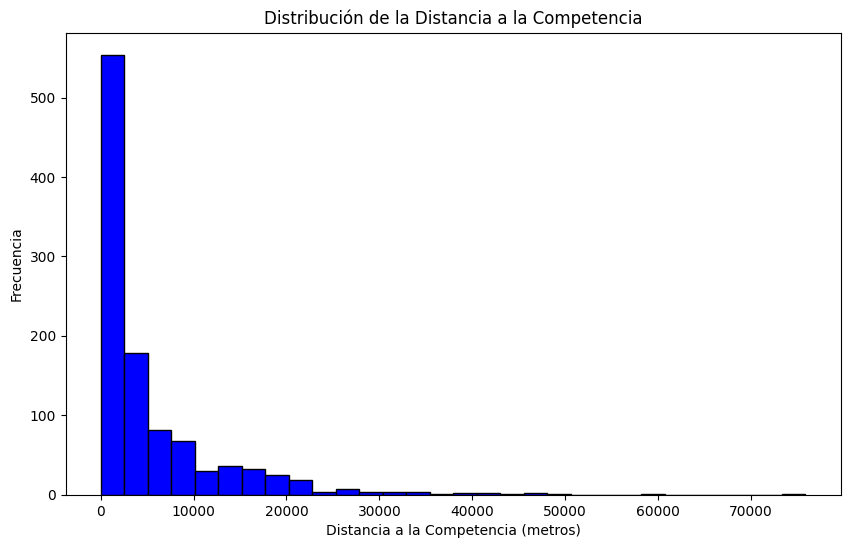

In [12]:
plt.figure(figsize=(10, 6))
plt.hist(df2_delete['CompetitionDistance'], bins=30, color='blue', edgecolor='black')
plt.title('Distribución de la Distancia a la Competencia')
plt.xlabel('Distancia a la Competencia (metros)')
plt.ylabel('Frecuencia')
plt.show()

El histograma muestra que la mayoría de las tiendas están ubicadas a menos de 1000 metros de su competidor más cercano, lo que indica una alta densidad competitiva. A medida que la distancia aumenta, la frecuencia de tiendas disminuye, mostrandonos que pocas tiendas están ubicadas lejos de su competencia.

La distribución es asimétrica hacia la izquierda, con pocas tiendas ubicadas a más de 5000 metros. Esto podría indicarnos que la competencia es más intensa en áreas donde las tiendas están cercas entre sí.

Luego, para analizar los patrones o agrupaciones, podemos usar un BoxPlot (gráfico de cajas y bigotes) para cada tienda. COn esto, podremos ver las diferencias en las distancias según el tipo de tienda.

<Figure size 1000x600 with 0 Axes>

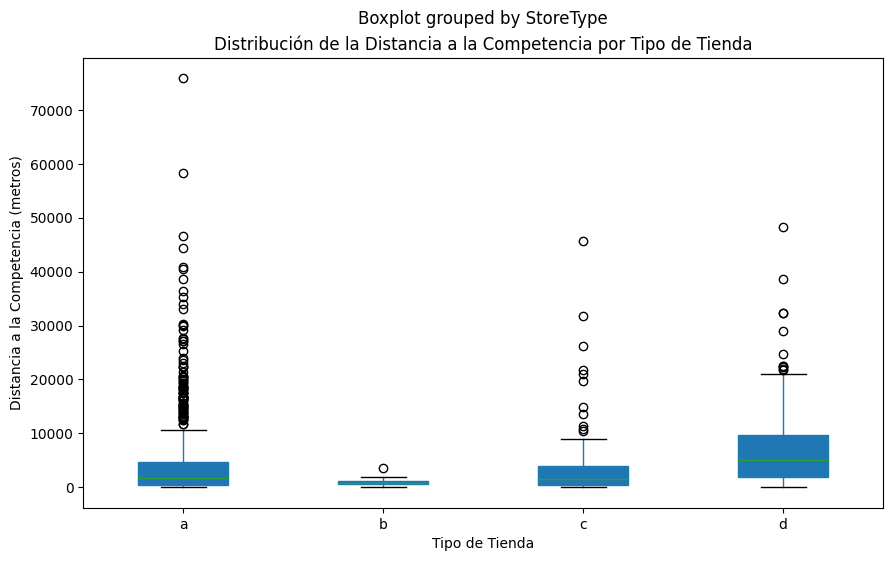

In [13]:
plt.figure(figsize=(10, 6))
df2_delete.boxplot(column='CompetitionDistance', by='StoreType', grid=False, figsize=(10, 6), patch_artist=True)
plt.title('Distribución de la Distancia a la Competencia por Tipo de Tienda')
plt.xlabel('Tipo de Tienda')
plt.ylabel('Distancia a la Competencia (metros)')
plt.show()

El gráfico de cajas y bigotes muestra que las tiendas de tipo "a" tienen una gran variabilidad en su distancia a la competencia, con algunas muy alejadas y varios outliers.

Las tiendas de tipo "b" están más cerca de la competencia y tienen menos variación.

Las tiendas de tipo "c" y "d" también muestran harta dispersión, con algunas muy cercanas y otras más alejadas de su competencia, pero sin tantos valores atípicos como el tipo "a".

En resumen, las tiendas de tipo "b" están generalmente más cerca de sus competidores que los otros tipos de tiendas.

**Paso 6:**

Como los datos de las ventas no tienen información sobre el tipo de tienda, primero los unimos con la información del tipo de tienda. Utilizamos la función `pd.merge()` para unir los dos conjuntos de datos en base al identificador `Store`.

In [14]:
merged_data = pd.merge(df1_delete, df2_delete[['Store', 'StoreType']], on='Store')

Ahora calcularemos las ventas totales por tienda, para ello ocuparemos `groupby()` y `sum()`


In [15]:
ventas_totales_tiendas = merged_data.groupby('Store')['Sales'].sum().reset_index()

Ahora, vamos a unir el tipo de tienda con las ventas totales de cada tienda.

In [16]:
ventas_totales_tiendas = pd.merge(ventas_totales_tiendas, df2_delete[['Store', 'StoreType']], on='Store')


Luego, calcularemos las ventas totales por tipo de tienda.

Para poder calcular el HHI, necesitamos las ventas totales por cada tipo de tienda. Utilizamos `groupby()` de nuevo, pero esta vez agrupamos por `StoreType`:

In [17]:
ventas_tipos = ventas_totales_tiendas.groupby('StoreType')['Sales'].sum()

Para calcular el HHI para cada tipo de tienda,  calculamos la participación de mercado (es decir, las ventas de cada tienda divididas por las ventas totales de su tipo) y luego sumamos los cuadrados de esas participaciones:

In [18]:
hhi_tipo = {}

for tipo in ventas_totales_tiendas['StoreType'].unique():
    tiendas_tipos = ventas_totales_tiendas[ventas_totales_tiendas['StoreType'] == tipo]
    total_ventas_tipos = ventas_tipos[tipo]

    p_mercado = (tiendas_tipos['Sales'] / total_ventas_tipos) ** 2
    hhi_tipo[tipo] = p_mercado.sum() * 10000

Mostramos los resultados HHI

In [19]:
for tipo, hhi in hhi_tipo.items():
    print(f'Tipo de Tienda {tipo}: HHI = {hhi:.2f}')


Tipo de Tienda c: HHI = 79.48
Tipo de Tienda a: HHI = 20.07
Tipo de Tienda d: HHI = 33.04
Tipo de Tienda b: HHI = 711.49
